# M5 Series Analysis

Loads the processed Parquet dataset and validates it for the monthly SKU forecasting pipeline.

```bash
uv run jupyter notebook notebooks/m5_series_analysis.ipynb
```

Prerequisite: run `uv run python scripts/extract_m5.py` first.

The extract script keeps the **top 50 SKUs** by total demand across all stores and dates.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from data.loader import validate_sales_schema
from preprocessing.transform import aggregate_monthly_by_sku

OUTPUT_PATH = PROJECT_ROOT / "data" / "m5" / "processed" / "m5_daily_sales.parquet"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset: {OUTPUT_PATH}")

Project root: /Users/alissonrodrigues/personal/forecasting-project
Dataset: /Users/alissonrodrigues/personal/forecasting-project/data/m5/processed/m5_daily_sales.parquet


## 1. Load daily sales

In [2]:
daily = pd.read_parquet(OUTPUT_PATH)

print(f"Rows: {len(daily):,}")
print(f"SKUs: {daily['item_id'].nunique()}")
print(f"Stores: {daily['store_id'].nunique()}")
print(f"Date range: {daily['date'].min().date()} → {daily['date'].max().date()}")
daily.head()

Rows: 933,648
SKUs: 50
Stores: 10
Date range: 2011-01-29 → 2016-06-19


,date,item_id,store_id,sales
0,2011-01-29,FOODS_1_218,CA_1,10.0
1,2011-01-30,FOODS_1_218,CA_1,3.0
2,2011-01-31,FOODS_1_218,CA_1,4.0
3,2011-02-01,FOODS_1_218,CA_1,0.0
4,2011-02-02,FOODS_1_218,CA_1,0.0


## 2. Schema validation

In [3]:
validated = validate_sales_schema(daily)
print("Schema validation passed.")
validated.describe(include="all")

Validating sales data schema...
  → Schema validated successfully
Schema validation passed.


,date,item_id,store_id,sales
count,933648,933648,933648,933648.000000
unique,NaN,50,10,NaN
top,NaN,FOODS_1_218,TX_1,NaN
freq,NaN,19690,93825,NaN
mean,2013-11-15 11:16:28.514729,NaN,NaN,14.649796
min,2011-01-29 00:00:00,NaN,NaN,0.000000
25%,2012-08-05 00:00:00,NaN,NaN,3.000000
50%,2013-11-29 00:00:00,NaN,NaN,9.000000
75%,2015-03-11 00:00:00,NaN,NaN,19.000000
max,2016-06-19 00:00:00,NaN,NaN,763.000000


## 3. Monthly aggregation (pipeline step)

In [4]:
monthly = aggregate_monthly_by_sku(daily)
monthly.head()

Aggregating daily sales into monthly totals per SKU...
  → Aggregated to 3148 monthly records (50 SKUs)


,item_id,month,sales
0,FOODS_1_218,2011-01-01,149.0
1,FOODS_1_218,2011-02-01,663.0
2,FOODS_1_218,2011-03-01,1085.0
3,FOODS_1_218,2011-04-01,942.0
4,FOODS_1_218,2011-05-01,1050.0


## 4. Series coverage per SKU

How many months each SKU spans, and whether the history is long enough for lag features (lags up to 12 months in the pipeline).

In [5]:
coverage = (
    monthly.groupby("item_id")
    .agg(
        n_months=("month", "count"),
        start_month=("month", "min"),
        end_month=("month", "max"),
        total_sales=("sales", "sum"),
    )
    .sort_values("total_sales", ascending=False)
)
coverage["span_years"] = (
    (coverage["end_month"] - coverage["start_month"]).dt.days / 365.25
).round(2)

print(f"Global month range: {monthly['month'].min().date()} → {monthly['month'].max().date()}")
print(f"Months in dataset: {monthly['month'].nunique()}")
print(f"SKUs with ≥ 13 months (enough for lag_12): {(coverage['n_months'] >= 13).sum()} / {len(coverage)}")
coverage

Global month range: 2011-01-01 → 2016-06-01
Months in dataset: 66
SKUs with ≥ 13 months (enough for lag_12): 50 / 50


,n_months,start_month,end_month,total_sales,span_years
item_id,,,,,
FOODS_3_090,66,2011-01-01,2016-06-01,1034398.0,5.42
FOODS_3_586,66,2011-01-01,2016-06-01,945293.0,5.42
FOODS_3_252,66,2011-01-01,2016-06-01,584618.0,5.42
FOODS_3_555,66,2011-01-01,2016-06-01,505319.0,5.42
FOODS_3_714,66,2011-01-01,2016-06-01,409221.0,5.42
FOODS_3_587,66,2011-01-01,2016-06-01,408522.0,5.42
FOODS_3_694,66,2011-01-01,2016-06-01,402227.0,5.42
FOODS_3_226,66,2011-01-01,2016-06-01,374366.0,5.42
FOODS_3_202,66,2011-01-01,2016-06-01,306117.0,5.42


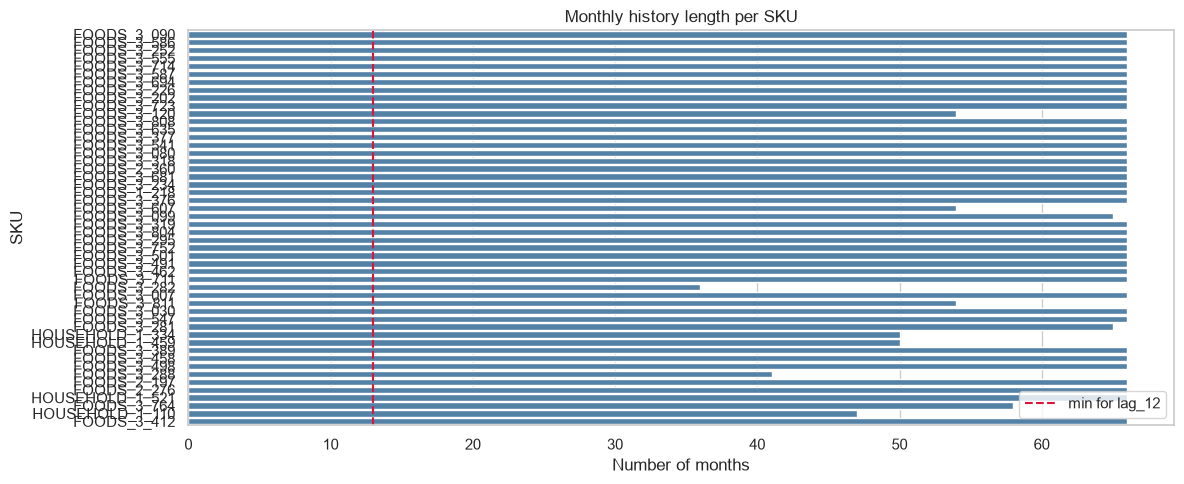

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=coverage.reset_index(),
    x="n_months",
    y="item_id",
    orient="h",
    order=coverage.index.tolist(),
    color="steelblue",
    ax=ax,
)
ax.axvline(13, color="crimson", linestyle="--", label="min for lag_12")
ax.set_xlabel("Number of months")
ax.set_ylabel("SKU")
ax.set_title("Monthly history length per SKU")
ax.legend()
plt.tight_layout()

## 5. Monthly volume time series

Each panel shows total monthly demand per SKU (aggregated across all stores).

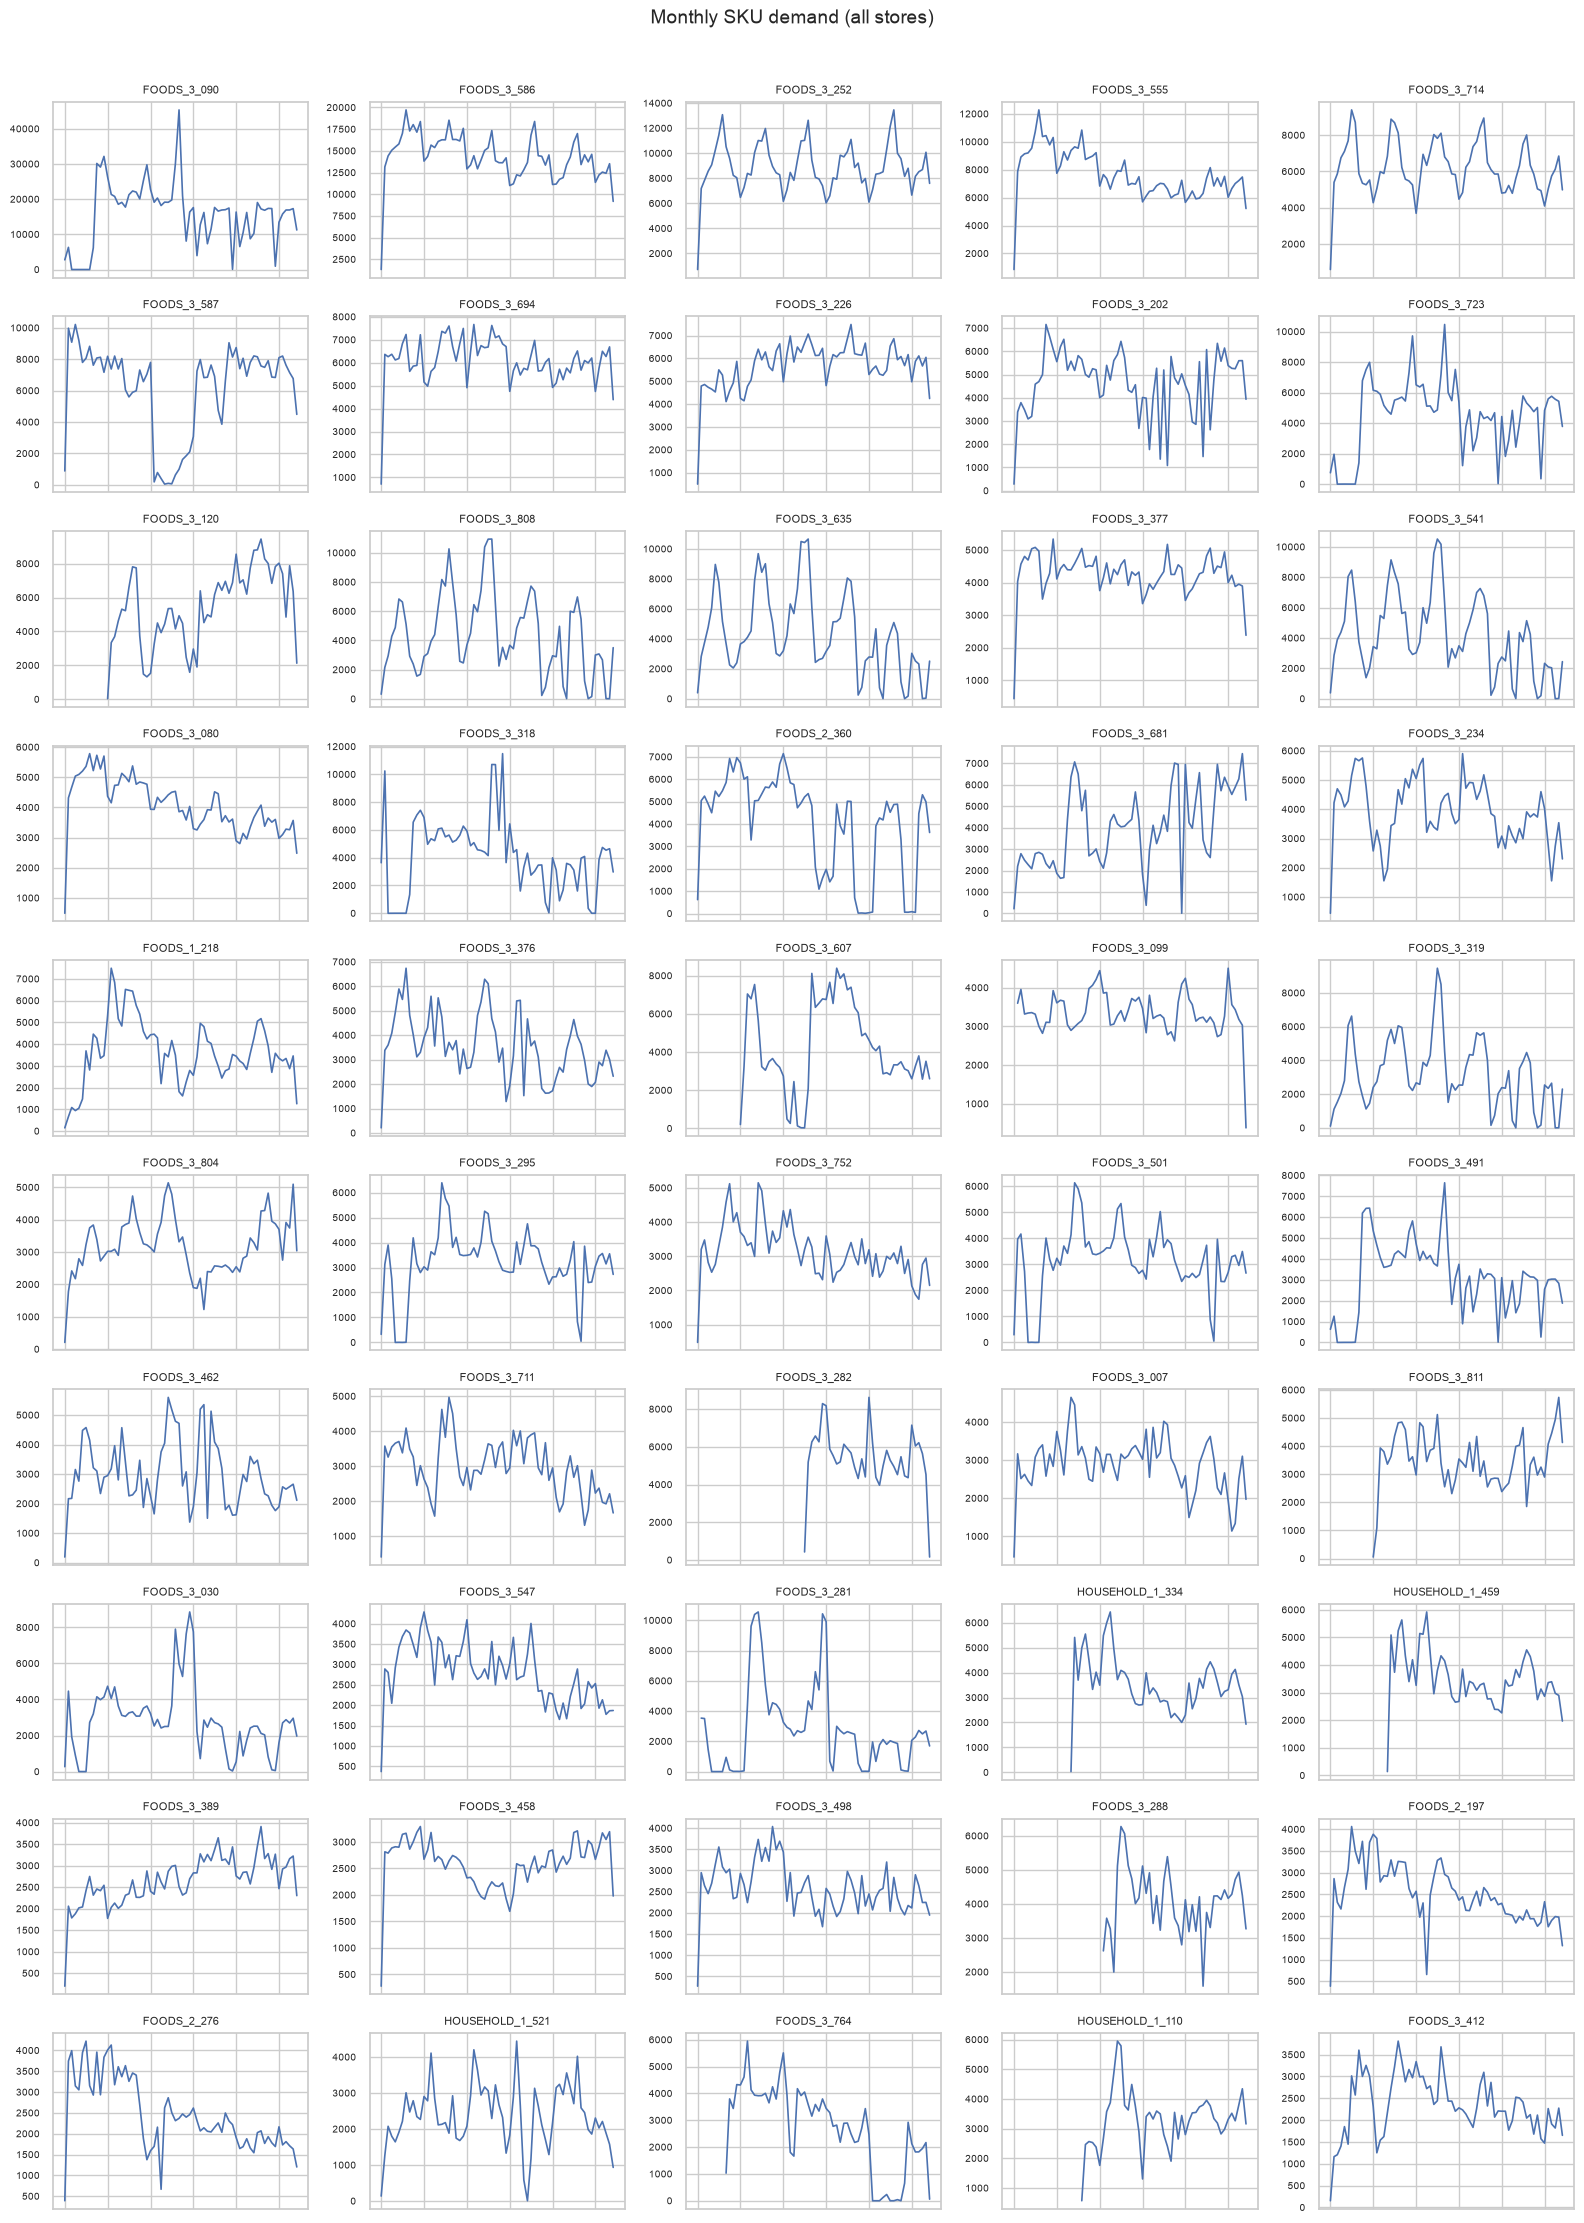

In [8]:
sku_order = coverage.index.tolist()
n_skus = len(sku_order)
ncols = 5
nrows = int(np.ceil(n_skus / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 2.2), sharex=True)
axes = axes.flatten()

for ax, sku in zip(axes, sku_order):
    series = monthly.loc[monthly["item_id"] == sku]
    ax.plot(series["month"], series["sales"], linewidth=1.2)
    ax.set_title(sku, fontsize=8)
    ax.tick_params(axis="both", labelsize=7)
    ax.set_xticklabels([])

for ax in axes[n_skus:]:
    ax.axis("off")

fig.suptitle("Monthly SKU demand (all stores)", y=1.01, fontsize=14)
plt.tight_layout()

## 6. Forecasting readiness metrics

Indicators to judge whether the series are suitable for monthly SKU forecasting:

| Metric | Interpretation |
|--------|----------------|
| `n_months` | History length; need ≥ 13 for `lag_12` + 1-step horizon |
| `zero_months_pct` | Intermittency — high values make point forecasts harder |
| `cv` | Coefficient of variation (std/mean) — higher = more volatile |
| `seasonality_index` | Peak month / mean month — stronger seasonal swings |
| `trend_slope` | Linear trend per month — drift in demand level |

In [9]:
def sku_forecast_metrics(monthly_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for sku, grp in monthly_df.groupby("item_id"):
        sales = grp["sales"].astype(float)
        cal_month = grp["month"].dt.month
        monthly_means = grp.groupby(cal_month)["sales"].mean()
        mean_sales = sales.mean()
        std_sales = sales.std()
        x = np.arange(len(sales))
        slope = np.polyfit(x, sales, 1)[0] if len(sales) > 1 else 0.0

        rows.append(
            {
                "item_id": sku,
                "n_months": len(grp),
                "start_month": grp["month"].min(),
                "end_month": grp["month"].max(),
                "total_sales": sales.sum(),
                "mean_monthly": mean_sales,
                "std_monthly": std_sales,
                "cv": std_sales / mean_sales if mean_sales > 0 else np.nan,
                "zero_months_pct": (sales == 0).mean(),
                "min_monthly": sales.min(),
                "max_monthly": sales.max(),
                "seasonality_index": (
                    monthly_means.max() / mean_sales if mean_sales > 0 else np.nan
                ),
                "trend_slope": slope,
            }
        )
    return pd.DataFrame(rows).sort_values("total_sales", ascending=False)

metrics = sku_forecast_metrics(monthly)
metrics.round(3)

/var/folders/74/slx1bhkx6m70xj7b6xb0svq40000gp/T/ipykernel_49965/1072330808.py:34: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  metrics.round(3)


,item_id,n_months,start_month,end_month,total_sales,mean_monthly,std_monthly,cv,zero_months_pct,min_monthly,max_monthly,seasonality_index,trend_slope
7,FOODS_3_090,66,2011-01-01,2016-06-01,1034398.0,15672.697,9080.738,0.579,0.091,0.0,45377.0,1.369,10.902
32,FOODS_3_586,66,2011-01-01,2016-06-01,945293.0,14322.621,2707.472,0.189,0.000,1323.0,19722.0,1.270,-42.115
13,FOODS_3_252,66,2011-01-01,2016-06-01,584618.0,8857.848,1970.844,0.222,0.000,719.0,13461.0,1.406,5.260
31,FOODS_3_555,66,2011-01-01,2016-06-01,505319.0,7656.348,1736.802,0.227,0.000,850.0,12284.0,1.217,-48.480
39,FOODS_3_714,66,2011-01-01,2016-06-01,409221.0,6200.318,1475.667,0.238,0.000,594.0,9394.0,1.352,-5.641
33,FOODS_3_587,66,2011-01-01,2016-06-01,408522.0,6189.727,2843.902,0.459,0.000,47.0,10215.0,1.124,0.621
37,FOODS_3_694,66,2011-01-01,2016-06-01,402227.0,6094.348,1016.820,0.167,0.000,708.0,7665.0,1.179,-4.280
11,FOODS_3_226,66,2011-01-01,2016-06-01,374366.0,5672.212,1011.602,0.178,0.000,497.0,7485.0,1.162,21.647
10,FOODS_3_202,66,2011-01-01,2016-06-01,306117.0,4638.136,1421.442,0.306,0.000,284.0,7155.0,1.212,0.241
40,FOODS_3_723,66,2011-01-01,2016-06-01,294546.0,4462.818,2396.265,0.537,0.061,0.0,10466.0,1.343,16.714


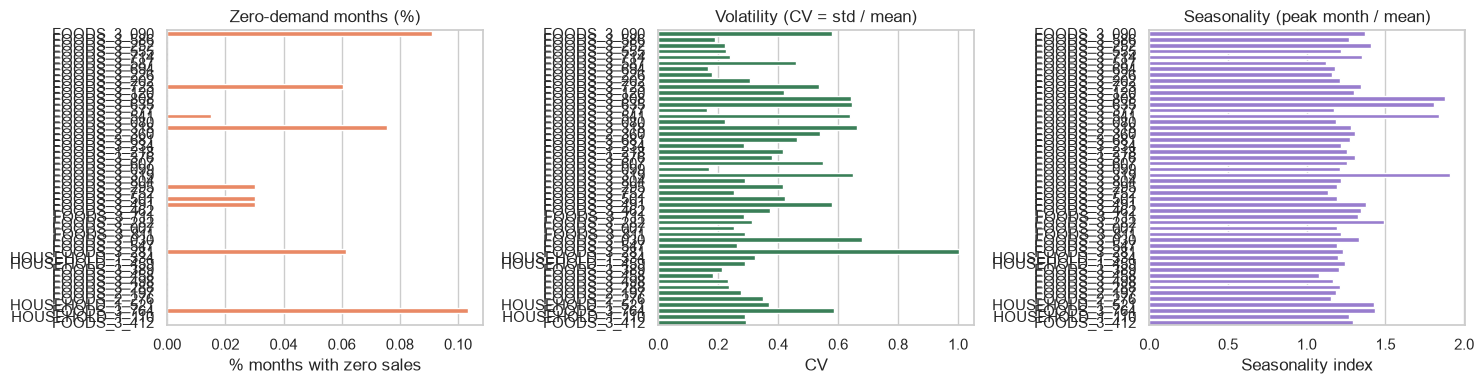

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=metrics, x="zero_months_pct", y="item_id", orient="h", ax=axes[0], color="coral")
axes[0].set_title("Zero-demand months (%)")
axes[0].set_xlabel("% months with zero sales")

sns.barplot(data=metrics, x="cv", y="item_id", orient="h", ax=axes[1], color="seagreen")
axes[1].set_title("Volatility (CV = std / mean)")
axes[1].set_xlabel("CV")

sns.barplot(data=metrics, x="seasonality_index", y="item_id", orient="h", ax=axes[2], color="mediumpurple")
axes[2].set_title("Seasonality (peak month / mean)")
axes[2].set_xlabel("Seasonality index")

for ax in axes:
    ax.set_ylabel("")

plt.tight_layout()

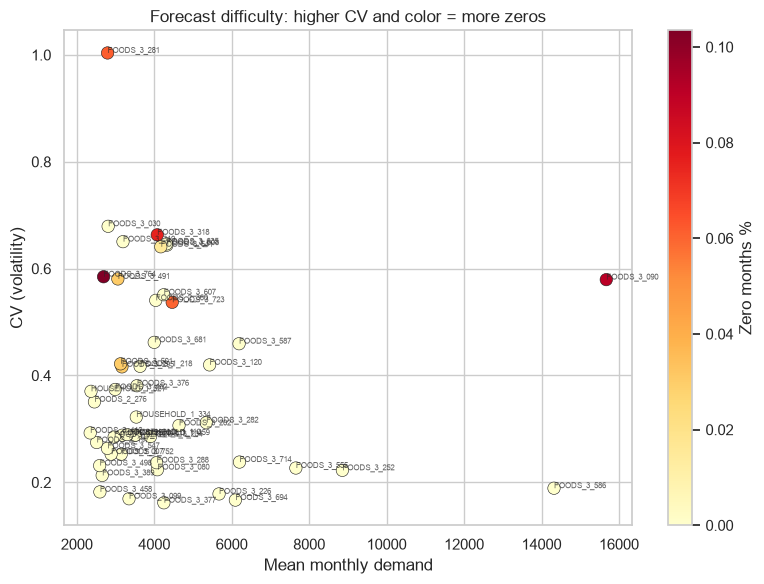

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    metrics["mean_monthly"],
    metrics["cv"],
    c=metrics["zero_months_pct"],
    cmap="YlOrRd",
    s=80,
    edgecolors="k",
    linewidths=0.4,
)
for _, row in metrics.iterrows():
    ax.annotate(row["item_id"], (row["mean_monthly"], row["cv"]), fontsize=6, alpha=0.7)
ax.set_xlabel("Mean monthly demand")
ax.set_ylabel("CV (volatility)")
ax.set_title("Forecast difficulty: higher CV and color = more zeros")
plt.colorbar(scatter, ax=ax, label="Zero months %")
plt.tight_layout()

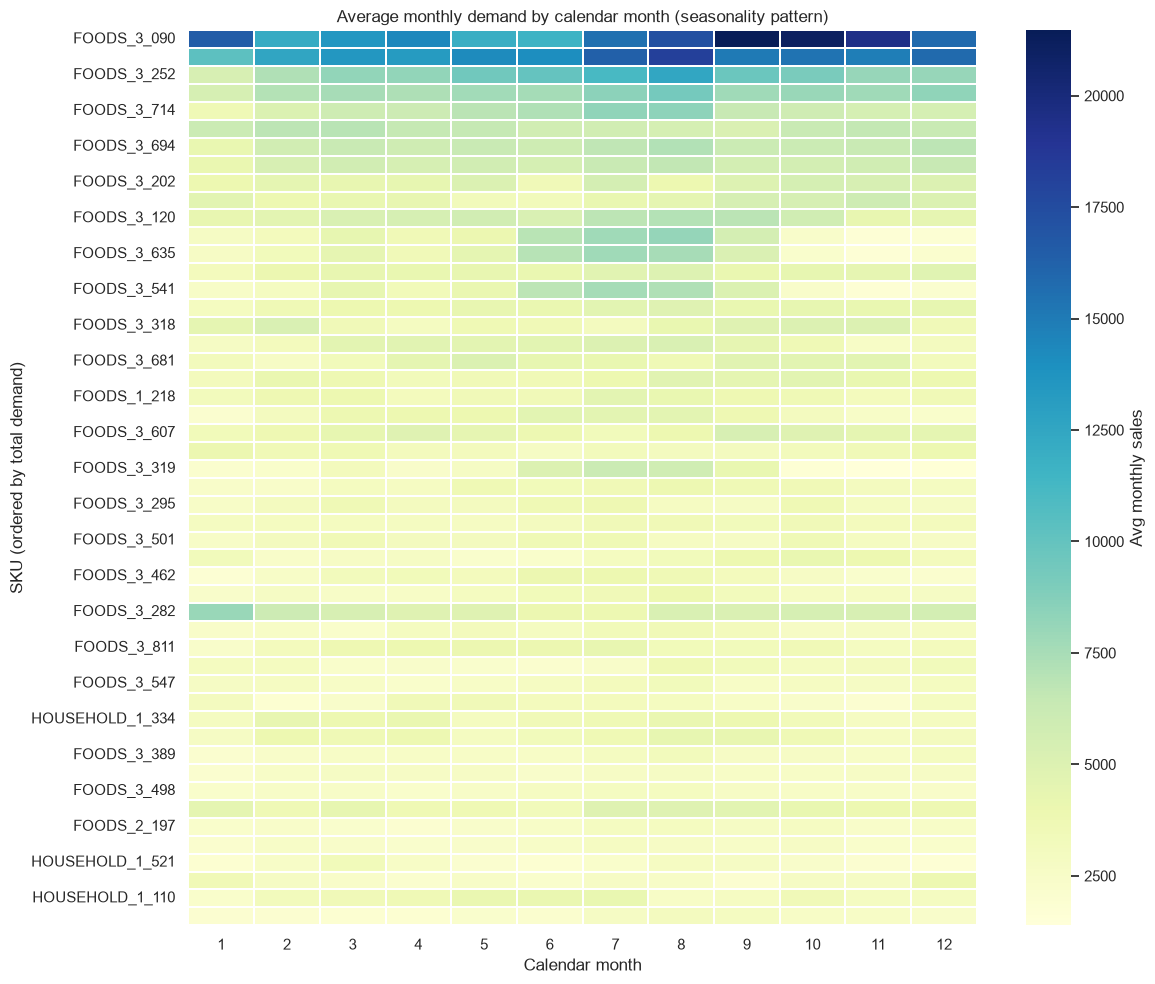

In [12]:
monthly_cal = monthly.copy()
monthly_cal["cal_month"] = monthly_cal["month"].dt.month
seasonal_profile = monthly_cal.groupby(["item_id", "cal_month"])["sales"].mean().reset_index()
seasonal_pivot = seasonal_profile.pivot(index="item_id", columns="cal_month", values="sales")
seasonal_pivot = seasonal_pivot.reindex(coverage.index)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    seasonal_pivot,
    cmap="YlGnBu",
    ax=ax,
    linewidths=0.2,
    cbar_kws={"label": "Avg monthly sales"},
)
ax.set_xlabel("Calendar month")
ax.set_ylabel("SKU (ordered by total demand)")
ax.set_title("Average monthly demand by calendar month (seasonality pattern)")
plt.tight_layout()

/var/folders/74/slx1bhkx6m70xj7b6xb0svq40000gp/T/ipykernel_49965/3016059121.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)


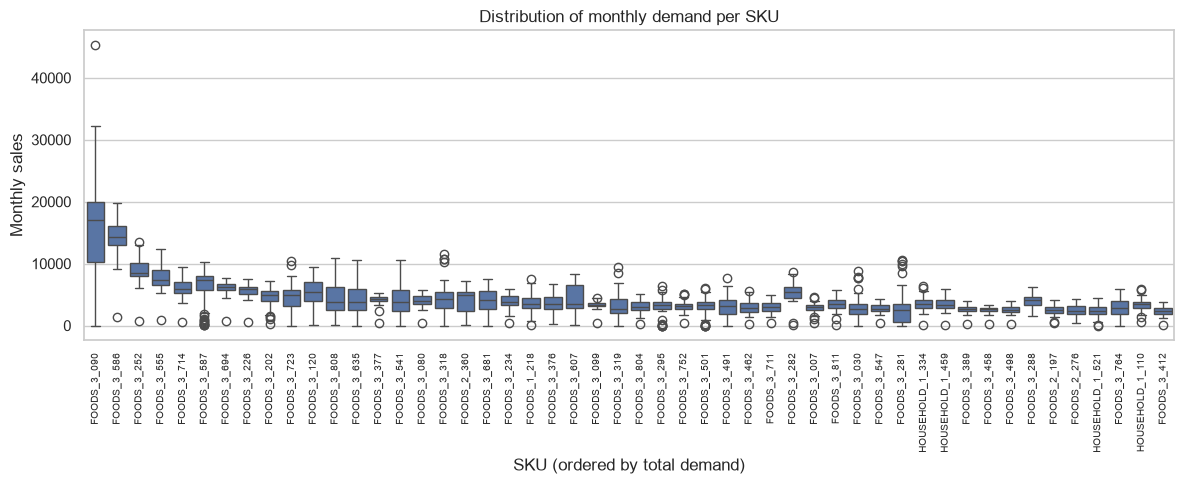

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=monthly, x="item_id", y="sales", order=coverage.index, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_title("Distribution of monthly demand per SKU")
ax.set_xlabel("SKU (ordered by total demand)")
ax.set_ylabel("Monthly sales")
plt.tight_layout()

## 7. Summary assessment

Quick flags for pipeline suitability (lag features: 1, 2, 3, 6, 12 months).

In [14]:
MIN_MONTHS = 13  # lag_12 + 1-step target
MAX_ZERO_PCT = 0.10
MAX_CV = 1.0

flags = metrics.copy()
flags["ok_history"] = flags["n_months"] >= MIN_MONTHS
flags["ok_intermittency"] = flags["zero_months_pct"] <= MAX_ZERO_PCT
flags["ok_volatility"] = flags["cv"] <= MAX_CV
flags["pipeline_ready"] = flags["ok_history"] & flags["ok_intermittency"] & flags["ok_volatility"]

print(f"Pipeline-ready SKUs: {flags['pipeline_ready'].sum()} / {len(flags)}")
print(f"  Short history (< {MIN_MONTHS} months): {(~flags['ok_history']).sum()}")
print(f"  High zero-month rate (> {MAX_ZERO_PCT:.0%}): {(~flags['ok_intermittency']).sum()}")
print(f"  High volatility (CV > {MAX_CV}): {(~flags['ok_volatility']).sum()}")

flags[[
    "item_id", "n_months", "zero_months_pct", "cv",
    "ok_history", "ok_intermittency", "ok_volatility", "pipeline_ready",
]].round(3)

Pipeline-ready SKUs: 48 / 50
  Short history (< 13 months): 0
  High zero-month rate (> 10%): 1
  High volatility (CV > 1.0): 1


,item_id,n_months,zero_months_pct,cv,ok_history,ok_intermittency,ok_volatility,pipeline_ready
7,FOODS_3_090,66,0.091,0.579,True,True,True,True
32,FOODS_3_586,66,0.000,0.189,True,True,True,True
13,FOODS_3_252,66,0.000,0.222,True,True,True,True
31,FOODS_3_555,66,0.000,0.227,True,True,True,True
39,FOODS_3_714,66,0.000,0.238,True,True,True,True
33,FOODS_3_587,66,0.000,0.459,True,True,True,True
37,FOODS_3_694,66,0.000,0.167,True,True,True,True
11,FOODS_3_226,66,0.000,0.178,True,True,True,True
10,FOODS_3_202,66,0.000,0.306,True,True,True,True
40,FOODS_3_723,66,0.061,0.537,True,True,True,True
